In [143]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import re
import numpy as np

splitbycap = '[A-Z][^A-Z]*'

matplotlib.rc('axes',edgecolor='k')
matplotlib.rc('xtick',labelsize=10)
matplotlib.rc('ytick',labelsize=10)
matplotlib.rc('axes',labelsize=16)
matplotlib.rc('axes',titlesize=16)
matplotlib.rc('axes',grid=False)

In [144]:
def get_data(path):
    with open(path, 'r') as f:
        data = json.load(f)
    return data

In [145]:
# alloy_pd = get_data('../DFTatMLIP results/alloy_space_overall_dict_EMPTY.json')

In [146]:
pure_phases_df = pd.read_parquet('pure_phases_df.parquet')
alloy_df = pd.read_parquet('alloy_df.parquet')
DOS_df = pd.read_parquet('dos_features.parquet')

In [147]:
DOS_columns_of_interest = ['formula', 'Efermi', 'vbm_up_energy', 'cbm_up_energy', 'vbm_down_energy', 'cbm_down_energy',
                           'is_alloy', 'x_frac', 'formula_0', 'formula_100']
# DOS_df[DOS_columns_of_interest]

In [148]:
data_columns_of_interest = ['formula', 'Eg', 'direct', 'dHf', 'dHd']

# alloy_df[data_columns_of_interest]
# pure_phases_df[data_columns_of_interest]

In [149]:
DOS_formulas = list(DOS_df['formula'])
data_formulas = list(alloy_df['formula'])+list(pure_phases_df['formula'])
count = 0
for formula in data_formulas:
    if formula not in DOS_formulas:
        # print(formula)
        count += 1
print(count, "formulas in data_df but not in DOS_df")


count = 0
for formula in DOS_formulas:
    if formula not in data_formulas:
        # print(formula)
        count += 1
print(count, "formulas in DOS_df but not in data_df")

163 formulas in data_df but not in DOS_df
385 formulas in DOS_df but not in data_df


In [150]:
def get_cbmvbm_Eg(band_edges: np.array) -> float:
    vbms = [band_edges[0][0], band_edges[0][1]]
    cbms = [band_edges[1][0], band_edges[1][1]]
    Eg_list = []
    for vbm in vbms:
        for cbm in cbms:
                Eg_list.append(cbm - vbm)
    return min(Eg_list)

In [151]:
# Exploratory Data Analysis (EDA), Verification
# extract cbm-vbm between up and down spins (up-up, down-down, up-down, down-up) from DOS_dict, take minimum
DOS_formulas_list = list(DOS_df['formula'])
vbm_up_energy_list = list(DOS_df['vbm_up_energy'])
cbm_up_energy_list = list(DOS_df['cbm_up_energy'])
vbm_down_energy_list = list(DOS_df['vbm_down_energy'])
cbm_down_energy_list = list(DOS_df['cbm_down_energy'])

cbm_vbm_Eg_dict = {}
for formula, vbm_up_energy, cbm_up_energy, vbm_down_energy, cbm_down_energy in zip(DOS_formulas_list, vbm_up_energy_list, cbm_up_energy_list, vbm_down_energy_list, cbm_down_energy_list):
    band_edges = np.array([[vbm_up_energy, vbm_down_energy], [cbm_up_energy, cbm_down_energy]])
    Eg = get_cbmvbm_Eg(band_edges)
    cbm_vbm_Eg_dict[formula] = Eg

# extract Eg from data_dict
data_formulas = list(alloy_df['formula'])+list(pure_phases_df['formula'])
data_Eg_list = list(alloy_df['Eg'])+list(pure_phases_df['Eg'])
data_Eg_dict = {}
for formula, Eg in zip(data_formulas, data_Eg_list):
    data_Eg_dict[formula] = Eg

# compare the two, there should be close matching if extraction using Claude Code is done correctly

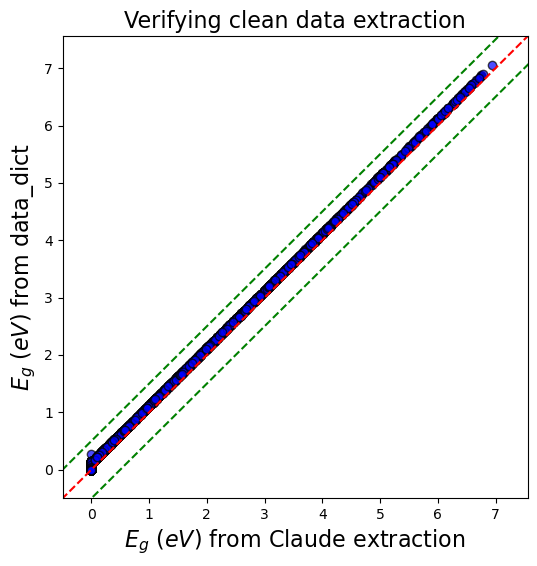

In [ ]:
formula_list = list(set(cbm_vbm_Eg_dict.keys()) & set(data_Eg_dict.keys())) # only formulas that are in both dicts, to compare the two Eg values
cbm_vbm_Eg_list = []
data_Eg_list = []
# mismatch_dict = {} #commented out because data extraction is now clean, no mismatches to analyze
# match_dict = {}
metallic_edge_cases = {}
for formula in formula_list:
    cbm_vbm_Eg_list.append(cbm_vbm_Eg_dict[formula])
    data_Eg_list.append(data_Eg_dict[formula])
    # mismatch = cbm_vbm_Eg_dict[formula]-data_Eg_dict[formula]
    # if abs(mismatch) > 0.5:
    #     mismatch_dict[formula] = mismatch
    # if abs(mismatch) <= 0.11:
    #     match_dict[formula] = mismatch
    if (data_Eg_dict[formula] == 0 and cbm_vbm_Eg_dict[formula] > 0) or (data_Eg_dict[formula] > 0 and cbm_vbm_Eg_dict[formula] == 0):
        metallic_edge_cases[formula] = (cbm_vbm_Eg_dict[formula], data_Eg_dict[formula])
    if 


plt.figure(figsize=(6,6))
plt.scatter(cbm_vbm_Eg_list, data_Eg_list, color='blue', marker='o', edgecolors='k', alpha=0.7)
plt.plot([-100, 100], [-100, 100], 'r--') # add y=x line for reference
plt.plot([-100, 100], [-100.5, 99.5], 'g--') # add y=x line for reference
plt.plot([-100, 100], [-99.5, 100.5], 'g--') # add y=x line for reference

plt.xlim(min(cbm_vbm_Eg_list+data_Eg_list)-0.5, max(cbm_vbm_Eg_list+data_Eg_list)+0.5)
plt.ylim(min(cbm_vbm_Eg_list+data_Eg_list)-0.5, max(cbm_vbm_Eg_list+data_Eg_list)+0.5)

plt.xlabel('$E_g$ $(eV)$ from Claude extraction')
plt.ylabel('$E_g$ $(eV)$ from data_dict')

plt.title('Verifying clean data extraction')

plt.show()



In [182]:
metallic_edge_cases

{'Rb2Cs2Fe3SnCl12': (0.0, 0.028000000000000025),
 'NaCsCu2Cl6': (0.0, 0.010600000000000054),
 'Rb2Cs2CaCr3I12': (0.0, 0.012499999999999734),
 'K4Ti3SrBr12': (0.0, 0.0032000000000000917),
 'K2Cs2Co3SrI12': (0.0, 0.03849999999999998),
 'Cs2TiPbBr6': (0.0, 0.1008),
 'K2Rb2Ti3SrBr12': (0.0, 0.05750000000000011),
 'K2Cs2Fe3PbCl12': (0.0, 0.04239999999999999),
 'Cs4Ti3BaBr12': (0.0, 0.04540000000000033),
 'Rb4Co3NiBr12': (0.0, 0.04579999999999984),
 'Rb2Cs2Co3NiCl12': (0.0, 0.018799999999999928),
 'Rb2Cs2Ti3BaCl12': (0.0, 0.007600000000000051),
 'RbCsV2Br6': (0.0, 0.09089999999999998),
 'K2Cs2Fe3CoBr12': (0.0, 0.015800000000000036),
 'RbCsCoPbI6': (0.0, 0.08319999999999994),
 'Rb2Cs2Pd3PbI12': (0.0, 0.04740000000000011),
 'Cs2CoSrF6': (0.0, 0.04239999999999977),
 'K2NiSrCl6': (0.0, 0.08860000000000001),
 'K2Cs2Ti3SrCl12': (0.0, 0.009199999999999875),
 'KCsCrMnI6': (0.0, 0.008000000000000007),
 'Cs2CaTiI6': (0.0, 0.14469999999999983),
 'Rb2Cs2MnFe3F12': (0.0, 0.028000000000000025),
 'KCsCaFeC

In [ ]:
# Exploratory Data Analysis (EDA), Trend Observation
# extract cbm-vbm between up and down spins (up-up, down-down, up-down, down-up) of PURE PHASES from DOS_dict, take minimum
# extract Eg from data_dict
# compare the two, observe trend